# Lab Assignment Four: Multi-Layer Perceptron

**Team Members:**
| Role | Name |
|---|---|
| Teammate 1 — Data Pipeline & Setup | |
| Teammate 2 — Preprocessing & 3-Layer MLP | Emilio Munoz|
| Teammate 3 — Deep Networks & Adaptive Learning | |

**Dataset:** ACS 2017 US Census Tract Data  
**Task:** Predict child poverty rate (4-class classification)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

---
## 1. Load, Split & Balance

### 1.1 Load & Clean

In [2]:
df = pd.read_csv('acs2017_census_tract_data.csv')
print('Shape:', df.shape)
df.head()

Shape: (74001, 37)


,TractId,State,County,TotalPop,Men,Women,Hispanic,White,Black,Native,...,Walk,OtherTransp,WorkAtHome,MeanCommute,Employed,PrivateWork,PublicWork,SelfEmployed,FamilyWork,Unemployment
0,1001020100,Alabama,Autauga County,1845,899,946,2.4,86.3,5.2,0.0,...,0.5,0.0,2.1,24.5,881,74.2,21.2,4.5,0.0,4.6
1,1001020200,Alabama,Autauga County,2172,1167,1005,1.1,41.6,54.5,0.0,...,0.0,0.5,0.0,22.2,852,75.9,15.0,9.0,0.0,3.4
2,1001020300,Alabama,Autauga County,3385,1533,1852,8.0,61.4,26.5,0.6,...,1.0,0.8,1.5,23.1,1482,73.3,21.1,4.8,0.7,4.7
3,1001020400,Alabama,Autauga County,4267,2001,2266,9.6,80.3,7.1,0.5,...,1.5,2.9,2.1,25.9,1849,75.8,19.7,4.5,0.0,6.1
4,1001020500,Alabama,Autauga County,9965,5054,4911,0.9,77.5,16.4,0.0,...,0.8,0.3,0.7,21.0,4787,71.4,24.1,4.5,0.0,2.3


In [3]:
df = df.dropna()
print('No NaN Shape:', df.shape)

No NaN Shape: (72718, 37)


In [4]:
string_cols = df.select_dtypes(include=['object']).columns.tolist()
print('String columns:', string_cols)

#encodes string columns to integers
le = LabelEncoder()
for col in string_cols:
    df[col] = le.fit_transform(df[col])

df.head()

String columns: ['State', 'County']


/var/folders/nb/hm103m4s4gn2lq5pjs_ypd7w0000gn/T/ipykernel_25269/446206272.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  string_cols = df.select_dtypes(include=['object']).columns.tolist()


,TractId,State,County,TotalPop,Men,Women,Hispanic,White,Black,Native,...,Walk,OtherTransp,WorkAtHome,MeanCommute,Employed,PrivateWork,PublicWork,SelfEmployed,FamilyWork,Unemployment
0,1001020100,0,89,1845,899,946,2.4,86.3,5.2,0.0,...,0.5,0.0,2.1,24.5,881,74.2,21.2,4.5,0.0,4.6
1,1001020200,0,89,2172,1167,1005,1.1,41.6,54.5,0.0,...,0.0,0.5,0.0,22.2,852,75.9,15.0,9.0,0.0,3.4
2,1001020300,0,89,3385,1533,1852,8.0,61.4,26.5,0.6,...,1.0,0.8,1.5,23.1,1482,73.3,21.1,4.8,0.7,4.7
3,1001020400,0,89,4267,2001,2266,9.6,80.3,7.1,0.5,...,1.5,2.9,2.1,25.9,1849,75.8,19.7,4.5,0.0,6.1
4,1001020500,0,89,9965,5054,4911,0.9,77.5,16.4,0.0,...,0.8,0.3,0.7,21.0,4787,71.4,24.1,4.5,0.0,2.3


### 1.2 County Variable Decision

**Discussion:** *(Should the `County` variable be kept or removed? Explain your reasoning.)*

I believe that the County variable should be kept. The dataset is a 2017 compilation of geographic and socioeconomic information collected across around 74,000 census tracts across the U.S. The dataset has 37 columns, each of which has information on geographic identifiers, population spread, race & ethnicity, transportation to work, employment, etc. The county column is a great indicator of a specific geoegraphical region, which could be helpful in understanding and analyzing different trends and patterns. Geography is generally a good indication of poverty and starvation, so having counties would likely help deduce more specific geographical locations where poverty is higher/more of a concern. Also, keeping county should add as an extra predictive column that will capture patterns in which other variables may miss. 

It is also reasonable to discuss how including county would cause some potential issues with the model. For example, because there are many distinct counties, this serves as an ID problem. Because the assignment asks us to one-hot encode later on, we already know that we'll get a few thousand new columns, which could confuse our model. 

In [5]:
#Decided to keep country 
print('Columns:', df.columns.tolist())

Columns: ['TractId', 'State', 'County', 'TotalPop', 'Men', 'Women', 'Hispanic', 'White', 'Black', 'Native', 'Asian', 'Pacific', 'VotingAgeCitizen', 'Income', 'IncomeErr', 'IncomePerCap', 'IncomePerCapErr', 'Poverty', 'ChildPoverty', 'Professional', 'Service', 'Office', 'Construction', 'Production', 'Drive', 'Carpool', 'Transit', 'Walk', 'OtherTransp', 'WorkAtHome', 'MeanCommute', 'Employed', 'PrivateWork', 'PublicWork', 'SelfEmployed', 'FamilyWork', 'Unemployment']


### 1.3 Quantize Target & Balance Dataset

Class distribution:
ChildPovertyClass
0    18229
1    18171
2    18148
3    18170
Name: count, dtype: int64


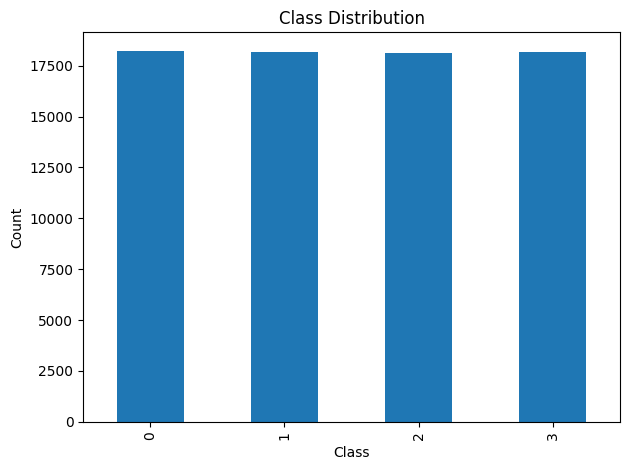

In [6]:
#Splits ChildPoverty column into 4 equally sized classes using quartile thresholids (qcut)
df['ChildPovertyClass'] = pd.qcut(df['ChildPoverty'], q=4, labels=[0, 1, 2, 3]).astype(int)

#Verficiation
print('Class distribution:')
print(df['ChildPovertyClass'].value_counts().sort_index())

#visualization
df['ChildPovertyClass'].value_counts().sort_index().plot(kind='bar', title='Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**Discussion:** *(Should balancing be applied to both the training set and the test set? Explain.)*

Balancing should only be applied to the training set. Balancing is used to prevent models from being biased toward predicting a majority class. If balancing was applied to the testing set as well, it would skew accuracy metrics since the model should perform on real, unseen data. Balancing on testing data would cause inaccurate and misleading results, as models could perform very poorly on unbalanced data compared to balanced data. 

### 1.4 Train/Test Split (80/20)

In [7]:
#Define feature columns
#Excluded 'ChildPoverty' (original continuous target), 'ChildPovertyClass' (binned target), and 'TractId' (identifier)
feature_cols = [c for c in df.columns if c not in ['ChildPoverty', 'ChildPovertyClass', 'TractId']]
categorical_col_names = ['State', 'County']  # label-encoded categorical columns
all_cols = feature_cols

# Extract features and labels
X = df[feature_cols].values
y = df['ChildPovertyClass'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print('Train shape:', X_train.shape)
print('Test shape: ', X_test.shape)
print('Features:   ', all_cols)

Train shape: (58174, 35)
Test shape:  (14544, 35)
Features:    ['State', 'County', 'TotalPop', 'Men', 'Women', 'Hispanic', 'White', 'Black', 'Native', 'Asian', 'Pacific', 'VotingAgeCitizen', 'Income', 'IncomeErr', 'IncomePerCap', 'IncomePerCapErr', 'Poverty', 'Professional', 'Service', 'Office', 'Construction', 'Production', 'Drive', 'Carpool', 'Transit', 'Walk', 'OtherTransp', 'WorkAtHome', 'MeanCommute', 'Employed', 'PrivateWork', 'PublicWork', 'SelfEmployed', 'FamilyWork', 'Unemployment']


In [8]:
#one hot encoding 
Y_train = np.eye(4)[y_train]
Y_test  = np.eye(4)[y_test]

print('Y_train shape:', Y_train.shape) 
print('Y_test shape: ', Y_test.shape)   

Y_train shape: (58174, 4)
Y_test shape:  (14544, 4)


---
## 2. MLP Helper Functions & Base Classes

In [9]:
#Example adapted from https://github.com/rasbt/python-machine-learning-book/blob/master/code/ch12/ch12.ipynb
#Original Author: Sebastian Raschka

import numpy as np
from scipy.special import expit
import sys
import pandas as pd

# start with a simple base classifier, which can't be fit or predicted
# it only has internal classes to be used by classes that will subclass it
# Start with the following functions:
#    init
#    encode_labels
#    initialize weights
#    sigmoid
#    add bias (vector of ones)
#    objective function (cost and regularizer)
class TwoLayerPerceptronBase(object):
    def __init__(self, n_hidden=30,
                 C=0.0, epochs=500, eta=0.001, random_state=None):
        np.random.seed(random_state)
        self.n_hidden = n_hidden
        self.l2_C = C
        self.epochs = epochs
        self.eta = eta
        
    @staticmethod
    def _encode_labels(y):
        """Encode labels into one-hot representation"""
        onehot = pd.get_dummies(y).values.T
            
        return onehot

    def _initialize_weights(self):
        """Initialize weights with small random numbers."""
        W1_num_elems = (self.n_features_ + 1)*self.n_hidden
        W1 = np.random.uniform(-1.0, 1.0, size=W1_num_elems)
        W1 = W1.reshape(self.n_hidden, self.n_features_ + 1) # reshape to be W
        
        W2_num_elems = (self.n_hidden + 1)*self.n_output_
        W2 = np.random.uniform(-1.0, 1.0, size=W2_num_elems)
        W2 = W2.reshape(self.n_output_, self.n_hidden + 1)
        return W1, W2
    
    @staticmethod
    def _sigmoid(z):
        """Use scipy.special.expit to avoid overflow"""
        # 1.0 / (1.0 + np.exp(-z))
        return expit(z)
    
    @staticmethod
    def _add_bias_unit(X, how='column'):
        """Add bias unit (column or row of 1s) to array at index 0"""
        if how == 'column':
            ones = np.ones((X.shape[0], 1))
            X_new = np.hstack((ones, X))
        elif how == 'row':
            ones = np.ones((1, X.shape[1]))
            X_new = np.vstack((ones, X))
        return X_new
    
    @staticmethod
    def _L2_reg(lambda_, W1, W2):
        """Compute L2-regularization cost"""
        # only compute for non-bias terms
        return (lambda_) * np.sqrt(np.mean(W1[:, 1:] ** 2) + np.mean(W2[:, 1:] ** 2))
    
    def _cost(self,A3,Y_enc,W1,W2):
        '''Get the objective function value'''
        cost = np.mean((Y_enc-A3)**2)
        L2_term = self._L2_reg(self.l2_C, W1, W2)
        return cost + L2_term
# now let's add in the following functions:
#    feedforward
#    fit and predict
class TwoLayerPerceptron(TwoLayerPerceptronBase):
    def _feedforward(self, X, W1, W2):
        """Compute feedforward step
        -----------
        X : Input layer with original features.
        W1: Weight matrix for input layer -> hidden layer.
        W2: Weight matrix for hidden layer -> output layer.
        ----------
        a1-a3 : activations into layer (or output layer)
        z1-z2 : layer inputs 

        """
        A1 = self._add_bias_unit(X.T, how='row')
        Z1 = W1 @ A1
        A2 = self._sigmoid(Z1)
        A2 = self._add_bias_unit(A2, how='row')
        Z2 = W2 @ A2
        A3 = self._sigmoid(Z2)
        return A1, Z1, A2, Z2, A3
    
    def _get_gradient(self, A1, A2, A3, Z1, Z2, Y_enc, W1, W2):
        """ Compute gradient step using backpropagation.
        """
        # need to vectorize this computation!
        # See additional code and derivation below!
    
    def predict(self, X):
        """Predict class labels"""
        _, _, _, _, A3 = self._feedforward(X, self.W1, self.W2)
        y_pred = np.argmax(A3, axis=0)
        return y_pred
    
    
    def fit(self, X, y, print_progress=False):
        """ Learn weights from training data."""
        
        X_data, y_data = X.copy(), y.copy()
        Y_enc = self._encode_labels(y)
        
        # init weights and setup matrices
        self.n_features_ = X_data.shape[1]
        self.n_output_ = Y_enc.shape[0]
        self.W1, self.W2 = self._initialize_weights()

        self.cost_ = []
        for i in range(self.epochs):

            if print_progress>0 and (i+1)%print_progress==0:
                sys.stderr.write('\rEpoch: %d/%d' % (i+1, self.epochs))
                sys.stderr.flush()

            # feedforward all instances
            A1, Z1, A2, Z2, A3 = self._feedforward(X_data,self.W1,self.W2)
            
            cost = self._cost(A3,Y_enc,self.W1,self.W2)
            self.cost_.append(cost)

            # compute gradient via backpropagation
            grad1, grad2 = self._get_gradient(A1=A1, A2=A2, A3=A3, Z1=Z1, Z2=Z2, Y_enc=Y_enc,
                                              W1=self.W1, W2=self.W2)

            self.W1 -= self.eta * grad1
            self.W2 -= self.eta * grad2
            

        return self
class TwoLayerPerceptronVectorized(TwoLayerPerceptron):
    # just need a different gradient calculation
    def _get_gradient(self, A1, A2, A3, Z1, Z2, Y_enc, W1, W2):
        """ Compute gradient step using backpropagation.
        """
        # vectorized backpropagation
        V2 = -2*(Y_enc-A3)*A3*(1-A3)
        V1 = A2*(1-A2)*(W2.T @ V2)
        
        grad2 = V2 @ A2.T
        grad1 = V1[1:,:] @ A1.T
        
        
        # regularize weights that are not bias terms
        grad1[:, 1:] += W1[:, 1:] * self.l2_C
        grad2[:, 1:] += W2[:, 1:] * self.l2_C

        return grad1, grad2
# Example adapted from https://github.com/rasbt/python-machine-learning-book/blob/master/code/ch12/ch12.ipynb
# Original Author: Sebastian Raschka
# This is the optional book we use in the course, excellent intuitions and straightforward programming examples
# please note, however, that this code has been manipulated to reflect our assumptions and notation.
class TLPVectorizedMiniBatch(TwoLayerPerceptronVectorized):
    def __init__(self, alpha=0.1, decrease_const=0.0, shuffle=True, minibatches=1, **kwds):        
        # need to add to the original initializer 
        self.alpha = alpha
        self.decrease_const = decrease_const
        self.shuffle = shuffle
        self.minibatches = minibatches
        
        
        
        # but keep other keywords
        super().__init__(**kwds)

    def fit(self, X, y, print_progress=0):
        """ Learn weights from training data."""
        if isinstance(X, pd.DataFrame) or isinstance(X, pd.Series):
            X_data, y_data = X.copy().values, y.copy()
        else:
            X_data, y_data = X.copy(), y.copy()

        Y_enc = self._encode_labels(y)
        
        # init weights and setup matrices
        self.n_features_ = X_data.shape[1]
        self.n_output_ = Y_enc.shape[0]
        self.W1, self.W2 = self._initialize_weights()
        
        # start momentum at zero for previous updates
        rho_W1_prev = np.zeros(self.W1.shape) # for momentum
        rho_W2_prev = np.zeros(self.W2.shape) # for momentum

        self.cost_ = []
        for k in range(self.epochs):

            # adaptive learning rate
            eta = self.eta**(1+self.decrease_const*k)# decreasing learning rate
            eta = max(eta,self.eta/1000)
            # there are many forms of adaptive learning rates out there!

            if print_progress>0 and (k+1)%print_progress==0:
                sys.stderr.write('\rEpoch: %d/%d' % (k+1, self.epochs))
                sys.stderr.flush()

            if self.shuffle:
                ridx = np.random.permutation(y_data.shape[0])
                X_data, Y_enc = X_data[ridx], Y_enc[:, ridx]

            # use numpy split to split into equal sized batches 
            # num batches== self.minibatches
            mini = np.array_split(range(y_data.shape[0]), self.minibatches)
            mini_cost = []
            for idx in mini:

                # feedforward
                A1, Z1, A2, Z2, A3 = self._feedforward(X_data[idx],
                                                       self.W1,
                                                       self.W2)
                
                cost = self._cost(A3,Y_enc[:, idx],self.W1,self.W2)
                mini_cost.append(cost) # this appends cost of mini-batch only

                # compute gradient via backpropagation
                grad1, grad2 = self._get_gradient(A1=A1, A2=A2, A3=A3, Z1=Z1, Z2=Z2,
                                                  Y_enc=Y_enc[:, idx],
                                                  W1=self.W1, W2=self.W2)

                rho_W1, rho_W2 = eta * grad1, eta * grad2
                self.W1 -= (rho_W1 + (self.alpha * rho_W1_prev)) # update with momentum
                self.W2 -= (rho_W2 + (self.alpha * rho_W2_prev)) # update with momentum
                rho_W1_prev, rho_W2_prev = rho_W1, rho_W2

            self.cost_.append(mini_cost)
            
        return self



class TLPVectorizedMiniBatchCrossEntropyGlorot(TLPVectorizedMiniBatch):
    """Uses Initialize Weights"""
    

    def _initialize_weights(self):
        """Initialize weights Glorot and He normalization."""
        init_bound = 4*np.sqrt(6. / (self.n_hidden + self.n_features_ + 1))
        W1 = np.random.uniform(-init_bound, init_bound,(self.n_hidden, self.n_features_ + 1))
        W1[:,:1] = 0
        
        # reduce the final layer magnitude in order to balance the size of the gradients
        # between 
        init_bound = 4*np.sqrt(6 / (self.n_output_ + self.n_hidden + 1))
        W2 = np.random.uniform(-init_bound, init_bound,(self.n_output_, self.n_hidden + 1)) 
        W2[:,:1] = 0
        
        return W1, W2
    
    
    """Cost function that uses cross entropy"""
    def _cost(self,A3,Y_enc,W1,W2):
        '''Get the objective function value'''
        # cost = -np.mean(np.nan_to_num((Y_enc*np.log(A3)+(1-Y_enc)*np.log(1-A3))))
        # L2_term = self._L2_reg(self.l2_C, W1, W2)
        
        eps = 1e-7
        A3 = np.clip(A3, eps, 1 - eps)
        cost = -np.mean(Y_enc * np.log(A3 + eps) + (1 - Y_enc) * np.log(1 - A3 + eps))
        L2_term = self._L2_reg(self.l2_C, W1, W2)
        return cost + L2_term
    
    def _get_gradient(self, A1, A2, A3, Z1, Z2, Y_enc, W1, W2):
        """ Compute gradient step using backpropagation.
        """
        # vectorized backpropagation
        V2 = (A3-Y_enc) # <- this is only line that changed
        V1 = A2*(1-A2)*(W2.T @ V2)
        
        grad2 = V2 @ A2.T
        grad1 = V1[1:,:] @ A1.T
        
        # regularize weights that are not bias terms
        grad1[:, 1:] += W1[:, 1:] * self.l2_C
        grad2[:, 1:] += W2[:, 1:] * self.l2_C

        return grad1, grad2
    

In [10]:
# Function to convert data into format to test accuracy with
def convert_data(y_pred):
  returnMe = pd.DataFrame()
  
  returnMe['first_quartile'] = (y_pred == 0)
  returnMe['second_quartile'] = (y_pred == 1)
  returnMe['third_quartile'] = (y_pred == 2)
  returnMe['fourth_quartile'] = (y_pred == 3)

  return returnMe

---
## 3. Pre-processing & Initial Modeling

### Model 1 — No Normalization, No One-Hot Encoding

Epoch: 30/30

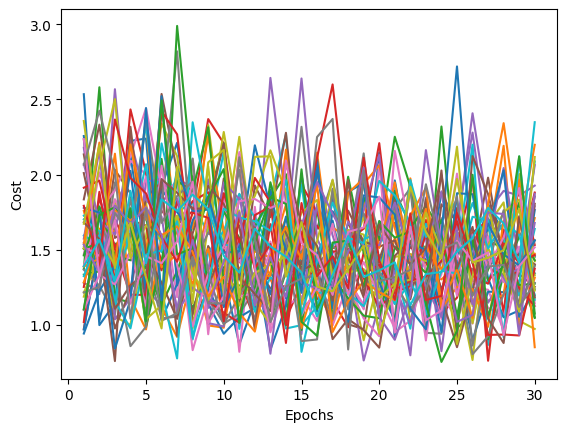

Accuracy: 0.24972497249724973


In [11]:
# train the model
from matplotlib import pyplot as plt
from sklearn.metrics import accuracy_score

params = { 'n_hidden':30, 
         'C':0.1, 'epochs':30, 'eta':0.001, 
         'alpha':0.001, 'decrease_const':1e-5, 'minibatches':50,
         'shuffle':True,'random_state':1}
# model = TLPVectorizedMiniBatchCrossEntropyGlorot(n_hidden=30, C=0.0, epochs=50, eta=0.001, random_state=42)
mlp1 = TLPVectorizedMiniBatchCrossEntropyGlorot(**params)
mlp1.fit(X_train, y_train, print_progress=True)
# plot the loss over time to ensure convergence
plt.plot(range(1, len(mlp1.cost_)+1), mlp1.cost_)
plt.xlabel("Epochs")
plt.ylabel("Cost")
plt.show()

# evaluate the mlp1 on the test set
y_pred = mlp1.predict(X_test)

# Get accuracy
acc1_test = accuracy_score(y_test, y_pred)
print("Accuracy:", acc1_test)

### Model 2 — Normalize Continuous Features

In [12]:
cont_indices = [i for i, col in enumerate(all_cols) if col not in categorical_col_names]
print(f'{len(cont_indices)} continuous features, {len(all_cols) - len(cont_indices)} categorical')

scaler = StandardScaler()
X_train_norm = X_train.copy().astype(float)
X_test_norm  = X_test.copy().astype(float)
X_train_norm[:, cont_indices] = scaler.fit_transform(X_train[:, cont_indices])
X_test_norm[:,  cont_indices] = scaler.transform(X_test[:, cont_indices])

33 continuous features, 2 categorical


Epoch: 1/30

Epoch: 30/30

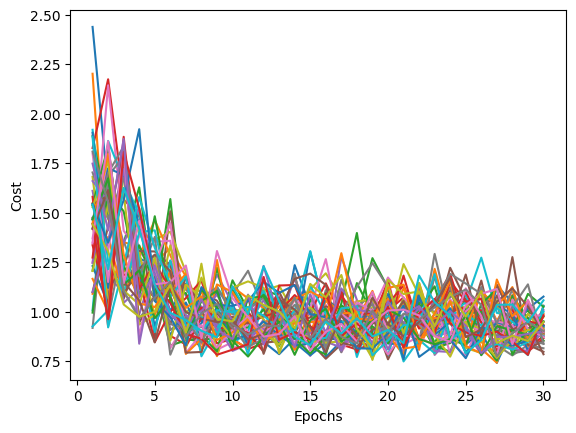

Accuracy: 0.2515126512651265


In [13]:
mlp2 = TLPVectorizedMiniBatchCrossEntropyGlorot(**params)
mlp2.fit(X_train_norm, y_train, print_progress=True)
# plot the loss over time to ensure convergence
plt.plot(range(1, len(mlp2.cost_)+1), mlp2.cost_)
plt.xlabel("Epochs")
plt.ylabel("Cost")
plt.show()

# evaluate the mlp2 on the test set
y_pred = mlp2.predict(X_test_norm)

# Get accuracy
acc2_test = accuracy_score(y_test, y_pred)
print("Accuracy:", acc2_test)

### Model 3 — Normalize Continuous + One-Hot Encode Categorical

In [14]:
cat_indices = [i for i, col in enumerate(all_cols) if col in categorical_col_names]
all_X = np.vstack([X_train, X_test])

def build_ohe(X_norm, cat_idx, all_X):
    cont_idx = [i for i in range(X_norm.shape[1]) if i not in cat_idx]
    parts = [X_norm[:, cont_idx]]
    for i in cat_idx:
        n_cats = int(all_X[:, i].max()) + 1
        parts.append(np.eye(n_cats)[X_norm[:, i].astype(int)])
    return np.hstack(parts)

X_train_ohe = build_ohe(X_train_norm, cat_indices, all_X)
X_test_ohe  = build_ohe(X_test_norm,  cat_indices, all_X)
print('X_train_ohe shape:', X_train_ohe.shape)

X_train_ohe shape: (58174, 2039)


Epoch: 30/30

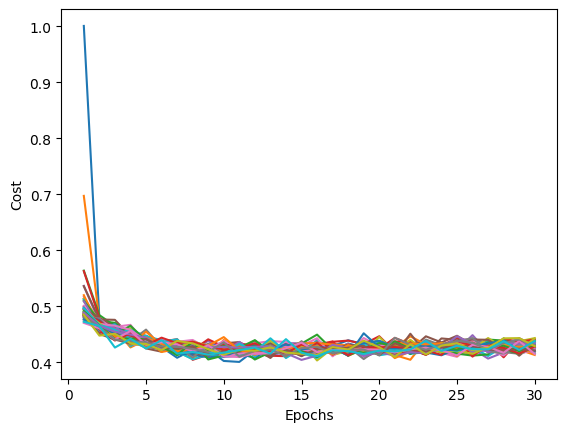

Accuracy: 0.7255913091309131


In [15]:
mlp3 = TLPVectorizedMiniBatchCrossEntropyGlorot(**params)
mlp3.fit(X_train_ohe, y_train, print_progress=True)
# plot the loss over time to ensure convergence
plt.plot(range(1, len(mlp3.cost_)+1), mlp3.cost_)
plt.xlabel("Epochs")
plt.ylabel("Cost")
plt.show()

# evaluate the mlp3 on the test set
y_pred = mlp3.predict(X_test_ohe)

# Get accuracy
acc3_test = accuracy_score(y_test, y_pred)
print("Accuracy:", acc3_test)

### Comparison: Models 1–3

               Model  Test Accuracy
1 — No Preprocessing       0.249725
      2 — Normalized       0.251513
3 — Normalized + OHE       0.725591


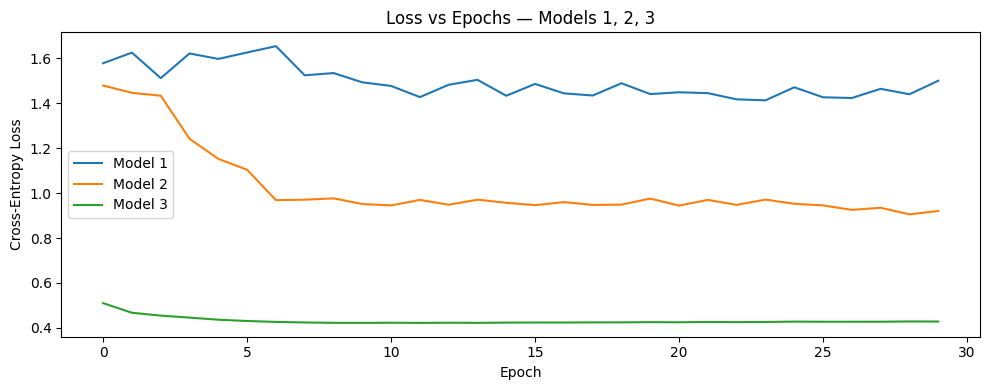

In [16]:
flat1 = [np.mean(epoch) for epoch in mlp1.cost_]
flat2 = [np.mean(epoch) for epoch in mlp2.cost_]
flat3 = [np.mean(epoch) for epoch in mlp3.cost_]

results = pd.DataFrame({
    'Model':         ['1 — No Preprocessing', '2 — Normalized', '3 — Normalized + OHE'],
    'Test Accuracy': [acc1_test, acc2_test, acc3_test]
})
print(results.to_string(index=False))

plt.figure(figsize=(10, 4))
plt.plot(flat1, label='Model 1')
plt.plot(flat2, label='Model 2')
plt.plot(flat3, label='Model 3')
plt.title('Loss vs Epochs — Models 1, 2, 3')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.legend()
plt.tight_layout()
plt.show()

### Discussion — Comparing Models 1, 2, and 3

There were pretty clear differences between the three models. Model 1 performed the worst with a test accuracy of ~25%, which is barely above random chance for a 4-class problem. The loss curve was noisy and unstable, oscillating between 1.4-1.6 the entire time without really converging. This makes sense since the raw features are on completely different scales, so the gradients end up being skewed toward those larger features and the network has a harder time learning.

Model 2 was noticeably better in terms of its loss curve, which dipped quickly from 1.4 and stabilized around 0.9, which shows that normalization significantly helped convergence. However, its test accuracy (~25.4%) was almost identical to Model 1, which was surprising. This suggests that while normalization improved training, the categorical features being label-encoded as arbitrary integers were still preventing the model from reaching high accuracies.

Model 3 added one-hot encoding on top of normalization and performed dramatically better. It achieved ~72.7% accuracy with a loss that converged quickly and leveled out around 0.4. The jump of accuracy from Model 2 to Model 3 shows that the categorical encoding was the main issue. Once the featuers State and County were represented not as meaningless integers, the model was able to identify geographic patterns that served as accurate predictors of child poverty rates.

---
## 4. Deeper MLPs with Gradient Magnitude Tracking

In [17]:
input_size = X_train_ohe.shape[1]

### 3-Layer MLP

In [18]:
class TLPVectorizedMiniBatchCrossEntropyGlorot3Layer(TLPVectorizedMiniBatchCrossEntropyGlorot):
    """3-Layer MLP extending the base class with an additional hidden layer."""

    def __init__(self, n_hidden2=30, **kwds):
        self.n_hidden2 = n_hidden2
        super().__init__(**kwds)

    def _initialize_weights(self):
        """Initialize weights with Glorot normalization for 3 layers."""
        init_bound = 4 * np.sqrt(6. / (self.n_hidden + self.n_features_ + 1))
        W1 = np.random.uniform(-init_bound, init_bound, (self.n_hidden, self.n_features_ + 1))
        W1[:, :1] = 0

        init_bound = 4 * np.sqrt(6. / (self.n_hidden2 + self.n_hidden + 1))
        W2 = np.random.uniform(-init_bound, init_bound, (self.n_hidden2, self.n_hidden + 1))
        W2[:, :1] = 0

        init_bound = 4 * np.sqrt(6. / (self.n_output_ + self.n_hidden2 + 1))
        W3 = np.random.uniform(-init_bound, init_bound, (self.n_output_, self.n_hidden2 + 1))
        W3[:, :1] = 0

        return W1, W2, W3

    def _feedforward(self, X, W1, W2, W3):
        """Feedforward through 3 layers."""
        A1 = self._add_bias_unit(X.T, how='row')
        Z1 = W1 @ A1
        A2 = self._sigmoid(Z1)
        A2 = self._add_bias_unit(A2, how='row')
        Z2 = W2 @ A2
        A3 = self._sigmoid(Z2)
        A3 = self._add_bias_unit(A3, how='row')
        Z3 = W3 @ A3
        A4 = self._sigmoid(Z3)
        return A1, Z1, A2, Z2, A3, Z3, A4

    def _get_gradient(self, A1, A2, A3, A4, Z1, Z2, Z3, Y_enc, W1, W2, W3):
        """Backpropagation through 3 layers."""
        V3 = (A4 - Y_enc)
        V2 = A3 * (1 - A3) * (W3.T @ V3)
        V1 = A2 * (1 - A2) * (W2.T @ V2[1:, :])

        grad3 = V3 @ A3.T
        grad2 = V2[1:, :] @ A2.T
        grad1 = V1[1:, :] @ A1.T

        grad1[:, 1:] += W1[:, 1:] * self.l2_C
        grad2[:, 1:] += W2[:, 1:] * self.l2_C
        grad3[:, 1:] += W3[:, 1:] * self.l2_C

        return grad1, grad2, grad3

    def _cost(self, A4, Y_enc, W1, W2, W3):
        """Cross-entropy cost for 3-layer network."""
        eps = 1e-7
        A4 = np.clip(A4, eps, 1 - eps)
        cost = -np.mean(Y_enc * np.log(A4 + eps) + (1 - Y_enc) * np.log(1 - A4 + eps))
        L2_term = (self.l2_C) * np.sqrt(
            np.mean(W1[:, 1:] ** 2) +
            np.mean(W2[:, 1:] ** 2) +
            np.mean(W3[:, 1:] ** 2)
        )
        return cost + L2_term

    def fit(self, X, y, print_progress=0):
        """Train the 3-layer network."""
        if isinstance(X, pd.DataFrame) or isinstance(X, pd.Series):
            X_data, y_data = X.copy().values, y.copy()
        else:
            X_data, y_data = X.copy(), y.copy()

        Y_enc = self._encode_labels(y)

        self.n_features_ = X_data.shape[1]
        self.n_output_ = Y_enc.shape[0]
        self.W1, self.W2, self.W3 = self._initialize_weights()

        rho_W1_prev = np.zeros(self.W1.shape)
        rho_W2_prev = np.zeros(self.W2.shape)
        rho_W3_prev = np.zeros(self.W3.shape)

        self.cost_ = []
        # track average gradient magnitude per layer per epoch
        self.grad_magnitudes_ = {'layer1': [], 'layer2': [], 'layer3': []}

        for k in range(self.epochs):
            eta = self.eta ** (1 + self.decrease_const * k)
            eta = max(eta, self.eta / 1000)

            if print_progress > 0 and (k + 1) % print_progress == 0:
                sys.stderr.write('\rEpoch: %d/%d' % (k + 1, self.epochs))
                sys.stderr.flush()

            if self.shuffle:
                ridx = np.random.permutation(y_data.shape[0])
                X_data, Y_enc = X_data[ridx], Y_enc[:, ridx]

            mini = np.array_split(range(y_data.shape[0]), self.minibatches)
            mini_cost = []

            # accumulate gradient magnitudes across mini-batches
            epoch_mag1, epoch_mag2, epoch_mag3 = [], [], []

            for idx in mini:
                A1, Z1, A2, Z2, A3, Z3, A4 = self._feedforward(
                    X_data[idx], self.W1, self.W2, self.W3)

                cost = self._cost(A4, Y_enc[:, idx], self.W1, self.W2, self.W3)
                mini_cost.append(cost)

                grad1, grad2, grad3 = self._get_gradient(
                    A1=A1, A2=A2, A3=A3, A4=A4,
                    Z1=Z1, Z2=Z2, Z3=Z3,
                    Y_enc=Y_enc[:, idx],
                    W1=self.W1, W2=self.W2, W3=self.W3
                )

                # track average absolute value of gradients per mini-batch
                epoch_mag1.append(np.mean(np.abs(grad1)))
                epoch_mag2.append(np.mean(np.abs(grad2)))
                epoch_mag3.append(np.mean(np.abs(grad3)))

                rho_W1, rho_W2, rho_W3 = eta * grad1, eta * grad2, eta * grad3
                self.W1 -= (rho_W1 + (self.alpha * rho_W1_prev))
                self.W2 -= (rho_W2 + (self.alpha * rho_W2_prev))
                self.W3 -= (rho_W3 + (self.alpha * rho_W3_prev))
                rho_W1_prev, rho_W2_prev, rho_W3_prev = rho_W1, rho_W2, rho_W3

            self.cost_.append(mini_cost)

            # average magnitude across all mini-batches for this epoch
            self.grad_magnitudes_['layer1'].append(np.mean(epoch_mag1))
            self.grad_magnitudes_['layer2'].append(np.mean(epoch_mag2))
            self.grad_magnitudes_['layer3'].append(np.mean(epoch_mag3))

        return self

    def predict(self, X):
        """Predict class labels."""
        _, _, _, _, _, _, A4 = self._feedforward(X, self.W1, self.W2, self.W3)
        return np.argmax(A4, axis=0)

    def plot_grad_magnitudes(self):
        """Plot average gradient magnitude per layer per epoch."""
        plt.figure(figsize=(9, 4))
        for layer, mags in self.grad_magnitudes_.items():
            plt.plot(mags, label=layer)
        plt.title('3-Layer MLP — Gradient Magnitudes per Layer')
        plt.xlabel('Epoch')
        plt.ylabel('Avg Gradient Magnitude')
        plt.legend()
        plt.tight_layout()
        plt.show()

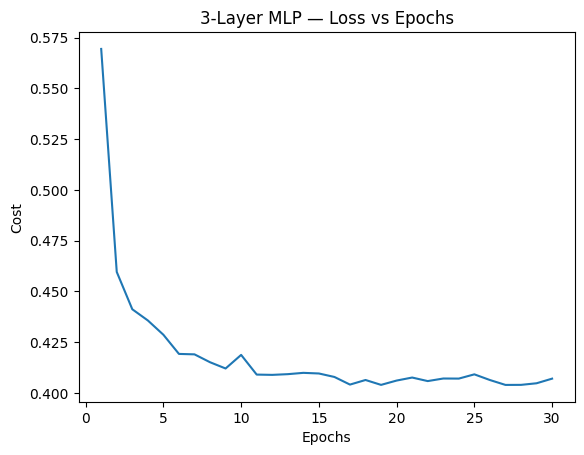

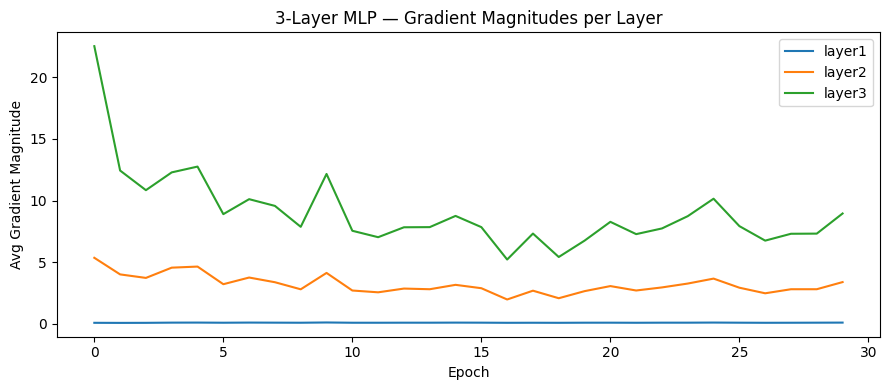

Accuracy: 0.7295104510451045


In [19]:
model3L = TLPVectorizedMiniBatchCrossEntropyGlorot3Layer(
    n_hidden=64, n_hidden2=32,
    C=0.1, epochs=30, eta=0.001,
    alpha=0.001, decrease_const=1e-5,
    minibatches=50, shuffle=True, random_state=1
)
model3L.fit(X_train_ohe, y_train, print_progress=50)

# plot loss
flat_costs = [np.mean(epoch) for epoch in model3L.cost_]
plt.plot(range(1, len(flat_costs)+1), flat_costs)
plt.xlabel('Epochs')
plt.ylabel('Cost')
plt.title('3-Layer MLP — Loss vs Epochs')
plt.show()

# plot gradient magnitudes
model3L.plot_grad_magnitudes()

# evaluate accuracy
y_pred = model3L.predict(X_test_ohe)
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

### 4-Layer MLP

In [20]:
class TLPVectorizedMiniBatchCrossEntropyGlorot4Layer(TLPVectorizedMiniBatchCrossEntropyGlorot3Layer):
    """4-Layer MLP extending the 3-layer class with an additional hidden layer."""

    def __init__(self, n_hidden3=16, **kwds):
        self.n_hidden3 = n_hidden3
        super().__init__(**kwds)

    def _initialize_weights(self):
        """Initialize weights with Glorot normalization for 4 layers."""
        init_bound = 4 * np.sqrt(6. / (self.n_hidden + self.n_features_ + 1))
        W1 = np.random.uniform(-init_bound, init_bound, (self.n_hidden, self.n_features_ + 1))
        W1[:, :1] = 0

        init_bound = 4 * np.sqrt(6. / (self.n_hidden2 + self.n_hidden + 1))
        W2 = np.random.uniform(-init_bound, init_bound, (self.n_hidden2, self.n_hidden + 1))
        W2[:, :1] = 0

        init_bound = 4 * np.sqrt(6. / (self.n_hidden3 + self.n_hidden2 + 1))
        W3 = np.random.uniform(-init_bound, init_bound, (self.n_hidden3, self.n_hidden2 + 1))
        W3[:, :1] = 0

        init_bound = 4 * np.sqrt(6. / (self.n_output_ + self.n_hidden3 + 1))
        W4 = np.random.uniform(-init_bound, init_bound, (self.n_output_, self.n_hidden3 + 1))
        W4[:, :1] = 0

        return W1, W2, W3, W4

    def _feedforward(self, X, W1, W2, W3, W4):
        """Feedforward through 4 layers."""
        A1 = self._add_bias_unit(X.T, how='row')
        Z1 = W1 @ A1
        A2 = self._sigmoid(Z1)
        A2 = self._add_bias_unit(A2, how='row')
        Z2 = W2 @ A2
        A3 = self._sigmoid(Z2)
        A3 = self._add_bias_unit(A3, how='row')
        Z3 = W3 @ A3
        A4 = self._sigmoid(Z3)
        A4 = self._add_bias_unit(A4, how='row')
        Z4 = W4 @ A4
        A5 = self._sigmoid(Z4)
        return A1, Z1, A2, Z2, A3, Z3, A4, Z4, A5

    def _get_gradient(self, A1, A2, A3, A4, A5, Z1, Z2, Z3, Z4, Y_enc, W1, W2, W3, W4):
        """Backpropagation through 4 layers."""
        V4 = (A5 - Y_enc)
        V3 = A4 * (1 - A4) * (W4.T @ V4)
        V2 = A3 * (1 - A3) * (W3.T @ V3[1:, :])
        V1 = A2 * (1 - A2) * (W2.T @ V2[1:, :])

        grad4 = V4 @ A4.T
        grad3 = V3[1:, :] @ A3.T
        grad2 = V2[1:, :] @ A2.T
        grad1 = V1[1:, :] @ A1.T

        grad1[:, 1:] += W1[:, 1:] * self.l2_C
        grad2[:, 1:] += W2[:, 1:] * self.l2_C
        grad3[:, 1:] += W3[:, 1:] * self.l2_C
        grad4[:, 1:] += W4[:, 1:] * self.l2_C

        return grad1, grad2, grad3, grad4

    def _cost(self, A5, Y_enc, W1, W2, W3, W4):
        """Cross-entropy cost for 4-layer network."""
        eps = 1e-7
        A5 = np.clip(A5, eps, 1 - eps)
        cost = -np.mean(Y_enc * np.log(A5 + eps) + (1 - Y_enc) * np.log(1 - A5 + eps))
        L2_term = (self.l2_C) * np.sqrt(
            np.mean(W1[:, 1:] ** 2) +
            np.mean(W2[:, 1:] ** 2) +
            np.mean(W3[:, 1:] ** 2) +
            np.mean(W4[:, 1:] ** 2)
        )
        return cost + L2_term

    def fit(self, X, y, print_progress=0):
        """Train the 4-layer network."""
        if isinstance(X, pd.DataFrame) or isinstance(X, pd.Series):
            X_data, y_data = X.copy().values, y.copy()
        else:
            X_data, y_data = X.copy(), y.copy()

        Y_enc = self._encode_labels(y)

        self.n_features_ = X_data.shape[1]
        self.n_output_ = Y_enc.shape[0]
        self.W1, self.W2, self.W3, self.W4 = self._initialize_weights()

        rho_W1_prev = np.zeros(self.W1.shape)
        rho_W2_prev = np.zeros(self.W2.shape)
        rho_W3_prev = np.zeros(self.W3.shape)
        rho_W4_prev = np.zeros(self.W4.shape)

        self.cost_ = []
        self.grad_magnitudes_ = {'layer1': [], 'layer2': [], 'layer3': [], 'layer4': []}

        for k in range(self.epochs):
            eta = self.eta ** (1 + self.decrease_const * k)
            eta = max(eta, self.eta / 1000)

            if print_progress > 0 and (k + 1) % print_progress == 0:
                sys.stderr.write('\rEpoch: %d/%d' % (k + 1, self.epochs))
                sys.stderr.flush()

            if self.shuffle:
                ridx = np.random.permutation(y_data.shape[0])
                X_data, Y_enc = X_data[ridx], Y_enc[:, ridx]

            mini = np.array_split(range(y_data.shape[0]), self.minibatches)
            mini_cost = []
            epoch_mag1, epoch_mag2, epoch_mag3, epoch_mag4 = [], [], [], []

            for idx in mini:
                A1, Z1, A2, Z2, A3, Z3, A4, Z4, A5 = self._feedforward(
                    X_data[idx], self.W1, self.W2, self.W3, self.W4)

                cost = self._cost(A5, Y_enc[:, idx], self.W1, self.W2, self.W3, self.W4)
                mini_cost.append(cost)

                grad1, grad2, grad3, grad4 = self._get_gradient(
                    A1=A1, A2=A2, A3=A3, A4=A4, A5=A5,
                    Z1=Z1, Z2=Z2, Z3=Z3, Z4=Z4,
                    Y_enc=Y_enc[:, idx],
                    W1=self.W1, W2=self.W2, W3=self.W3, W4=self.W4
                )

                epoch_mag1.append(np.mean(np.abs(grad1)))
                epoch_mag2.append(np.mean(np.abs(grad2)))
                epoch_mag3.append(np.mean(np.abs(grad3)))
                epoch_mag4.append(np.mean(np.abs(grad4)))

                rho_W1, rho_W2, rho_W3, rho_W4 = eta*grad1, eta*grad2, eta*grad3, eta*grad4
                self.W1 -= (rho_W1 + (self.alpha * rho_W1_prev))
                self.W2 -= (rho_W2 + (self.alpha * rho_W2_prev))
                self.W3 -= (rho_W3 + (self.alpha * rho_W3_prev))
                self.W4 -= (rho_W4 + (self.alpha * rho_W4_prev))
                rho_W1_prev, rho_W2_prev = rho_W1, rho_W2
                rho_W3_prev, rho_W4_prev = rho_W3, rho_W4

            self.cost_.append(mini_cost)
            self.grad_magnitudes_['layer1'].append(np.mean(epoch_mag1))
            self.grad_magnitudes_['layer2'].append(np.mean(epoch_mag2))
            self.grad_magnitudes_['layer3'].append(np.mean(epoch_mag3))
            self.grad_magnitudes_['layer4'].append(np.mean(epoch_mag4))

        return self

    def predict(self, X):
        """Predict class labels."""
        _, _, _, _, _, _, _, _, A5 = self._feedforward(X, self.W1, self.W2, self.W3, self.W4)
        return np.argmax(A5, axis=0)

    def plot_grad_magnitudes(self):
        """Plot average gradient magnitude per layer per epoch."""
        plt.figure(figsize=(9, 4))
        for layer, mags in self.grad_magnitudes_.items():
            plt.plot(mags, label=layer)
        plt.title('4-Layer MLP — Gradient Magnitudes per Layer')
        plt.xlabel('Epoch')
        plt.ylabel('Avg Gradient Magnitude')
        plt.legend()
        plt.tight_layout()
        plt.show()

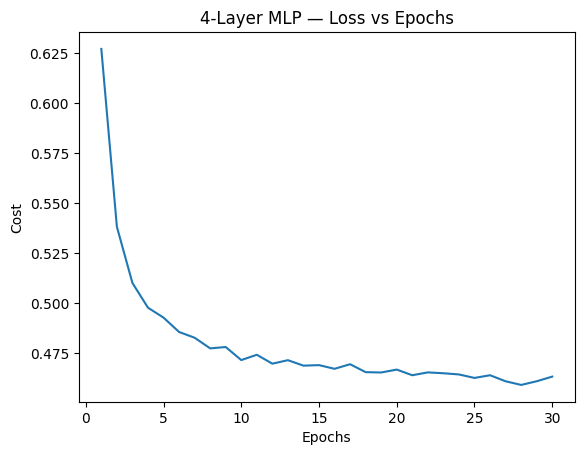

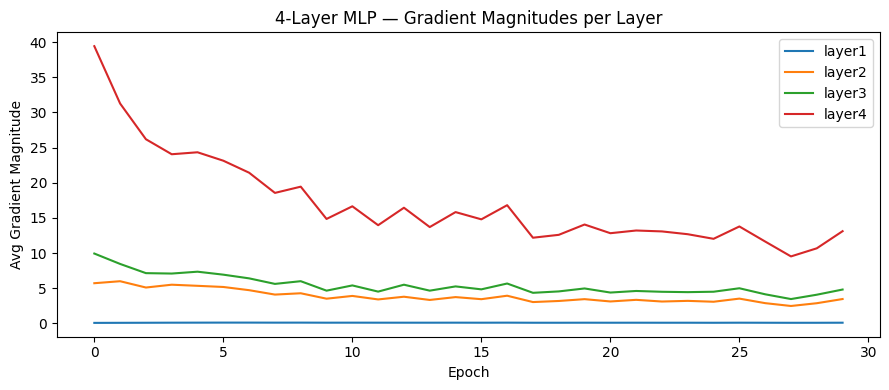

Accuracy: 0.7230473047304731


In [21]:
model4L = TLPVectorizedMiniBatchCrossEntropyGlorot4Layer(
    n_hidden=64, n_hidden2=32, n_hidden3=16,
    C=0.1, epochs=30, eta=0.001,
    alpha=0.001, decrease_const=1e-5,
    minibatches=50, shuffle=True, random_state=1
)
model4L.fit(X_train_ohe, y_train, print_progress=50)

# plot loss
flat_costs = [np.mean(epoch) for epoch in model4L.cost_]
plt.plot(range(1, len(flat_costs)+1), flat_costs)
plt.xlabel('Epochs')
plt.ylabel('Cost')
plt.title('4-Layer MLP — Loss vs Epochs')
plt.show()

# plot gradient magnitudes
model4L.plot_grad_magnitudes()

# evaluate accuracy
y_pred = model4L.predict(X_test_ohe)
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

### 5-Layer MLP

In [22]:
class TLPVectorizedMiniBatchCrossEntropyGlorot5Layer(TLPVectorizedMiniBatchCrossEntropyGlorot4Layer):
    """5-Layer MLP extending the 4-layer class with an additional hidden layer."""

    def __init__(self, n_hidden4=8, **kwds):
        self.n_hidden4 = n_hidden4
        super().__init__(**kwds)

    def _initialize_weights(self):
        """Initialize weights with Glorot normalization for 5 layers."""
        init_bound = 4 * np.sqrt(6. / (self.n_hidden + self.n_features_ + 1))
        W1 = np.random.uniform(-init_bound, init_bound, (self.n_hidden, self.n_features_ + 1))
        W1[:, :1] = 0

        init_bound = 4 * np.sqrt(6. / (self.n_hidden2 + self.n_hidden + 1))
        W2 = np.random.uniform(-init_bound, init_bound, (self.n_hidden2, self.n_hidden + 1))
        W2[:, :1] = 0

        init_bound = 4 * np.sqrt(6. / (self.n_hidden3 + self.n_hidden2 + 1))
        W3 = np.random.uniform(-init_bound, init_bound, (self.n_hidden3, self.n_hidden2 + 1))
        W3[:, :1] = 0

        init_bound = 4 * np.sqrt(6. / (self.n_hidden4 + self.n_hidden3 + 1))
        W4 = np.random.uniform(-init_bound, init_bound, (self.n_hidden4, self.n_hidden3 + 1))
        W4[:, :1] = 0

        init_bound = 4 * np.sqrt(6. / (self.n_output_ + self.n_hidden4 + 1))
        W5 = np.random.uniform(-init_bound, init_bound, (self.n_output_, self.n_hidden4 + 1))
        W5[:, :1] = 0

        return W1, W2, W3, W4, W5

    def _feedforward(self, X, W1, W2, W3, W4, W5):
        """Feedforward through 5 layers."""
        A1 = self._add_bias_unit(X.T, how='row')
        Z1 = W1 @ A1
        A2 = self._sigmoid(Z1)
        A2 = self._add_bias_unit(A2, how='row')
        Z2 = W2 @ A2
        A3 = self._sigmoid(Z2)
        A3 = self._add_bias_unit(A3, how='row')
        Z3 = W3 @ A3
        A4 = self._sigmoid(Z3)
        A4 = self._add_bias_unit(A4, how='row')
        Z4 = W4 @ A4
        A5 = self._sigmoid(Z4)
        A5 = self._add_bias_unit(A5, how='row')
        Z5 = W5 @ A5
        A6 = self._sigmoid(Z5)
        return A1, Z1, A2, Z2, A3, Z3, A4, Z4, A5, Z5, A6

    def _get_gradient(self, A1, A2, A3, A4, A5, A6, Z1, Z2, Z3, Z4, Z5, Y_enc, W1, W2, W3, W4, W5):
        """Backpropagation through 5 layers."""
        V5 = (A6 - Y_enc)
        V4 = A5 * (1 - A5) * (W5.T @ V5)
        V3 = A4 * (1 - A4) * (W4.T @ V4[1:, :])
        V2 = A3 * (1 - A3) * (W3.T @ V3[1:, :])
        V1 = A2 * (1 - A2) * (W2.T @ V2[1:, :])

        grad5 = V5 @ A5.T
        grad4 = V4[1:, :] @ A4.T
        grad3 = V3[1:, :] @ A3.T
        grad2 = V2[1:, :] @ A2.T
        grad1 = V1[1:, :] @ A1.T

        grad1[:, 1:] += W1[:, 1:] * self.l2_C
        grad2[:, 1:] += W2[:, 1:] * self.l2_C
        grad3[:, 1:] += W3[:, 1:] * self.l2_C
        grad4[:, 1:] += W4[:, 1:] * self.l2_C
        grad5[:, 1:] += W5[:, 1:] * self.l2_C

        return grad1, grad2, grad3, grad4, grad5

    def _cost(self, A6, Y_enc, W1, W2, W3, W4, W5):
        """Cross-entropy cost for 5-layer network."""
        eps = 1e-7
        A6 = np.clip(A6, eps, 1 - eps)
        cost = -np.mean(Y_enc * np.log(A6 + eps) + (1 - Y_enc) * np.log(1 - A6 + eps))
        L2_term = (self.l2_C) * np.sqrt(
            np.mean(W1[:, 1:] ** 2) +
            np.mean(W2[:, 1:] ** 2) +
            np.mean(W3[:, 1:] ** 2) +
            np.mean(W4[:, 1:] ** 2) +
            np.mean(W5[:, 1:] ** 2)
        )
        return cost + L2_term

    def fit(self, X, y, print_progress=0):
        """Train the 5-layer network."""
        if isinstance(X, pd.DataFrame) or isinstance(X, pd.Series):
            X_data, y_data = X.copy().values, y.copy()
        else:
            X_data, y_data = X.copy(), y.copy()

        Y_enc = self._encode_labels(y)

        self.n_features_ = X_data.shape[1]
        self.n_output_ = Y_enc.shape[0]
        self.W1, self.W2, self.W3, self.W4, self.W5 = self._initialize_weights()

        rho_W1_prev = np.zeros(self.W1.shape)
        rho_W2_prev = np.zeros(self.W2.shape)
        rho_W3_prev = np.zeros(self.W3.shape)
        rho_W4_prev = np.zeros(self.W4.shape)
        rho_W5_prev = np.zeros(self.W5.shape)

        self.cost_ = []
        self.grad_magnitudes_ = {
            'layer1': [], 'layer2': [], 'layer3': [],
            'layer4': [], 'layer5': []
        }

        for k in range(self.epochs):
            eta = self.eta ** (1 + self.decrease_const * k)
            eta = max(eta, self.eta / 1000)

            if print_progress > 0 and (k + 1) % print_progress == 0:
                sys.stderr.write('\rEpoch: %d/%d' % (k + 1, self.epochs))
                sys.stderr.flush()

            if self.shuffle:
                ridx = np.random.permutation(y_data.shape[0])
                X_data, Y_enc = X_data[ridx], Y_enc[:, ridx]

            mini = np.array_split(range(y_data.shape[0]), self.minibatches)
            mini_cost = []
            epoch_mag1, epoch_mag2, epoch_mag3 = [], [], []
            epoch_mag4, epoch_mag5 = [], []

            for idx in mini:
                A1, Z1, A2, Z2, A3, Z3, A4, Z4, A5, Z5, A6 = self._feedforward(
                    X_data[idx], self.W1, self.W2, self.W3, self.W4, self.W5)

                cost = self._cost(A6, Y_enc[:, idx], self.W1, self.W2, self.W3, self.W4, self.W5)
                mini_cost.append(cost)

                grad1, grad2, grad3, grad4, grad5 = self._get_gradient(
                    A1=A1, A2=A2, A3=A3, A4=A4, A5=A5, A6=A6,
                    Z1=Z1, Z2=Z2, Z3=Z3, Z4=Z4, Z5=Z5,
                    Y_enc=Y_enc[:, idx],
                    W1=self.W1, W2=self.W2, W3=self.W3, W4=self.W4, W5=self.W5
                )

                epoch_mag1.append(np.mean(np.abs(grad1)))
                epoch_mag2.append(np.mean(np.abs(grad2)))
                epoch_mag3.append(np.mean(np.abs(grad3)))
                epoch_mag4.append(np.mean(np.abs(grad4)))
                epoch_mag5.append(np.mean(np.abs(grad5)))

                rho_W1, rho_W2 = eta * grad1, eta * grad2
                rho_W3, rho_W4 = eta * grad3, eta * grad4
                rho_W5 = eta * grad5

                self.W1 -= (rho_W1 + (self.alpha * rho_W1_prev))
                self.W2 -= (rho_W2 + (self.alpha * rho_W2_prev))
                self.W3 -= (rho_W3 + (self.alpha * rho_W3_prev))
                self.W4 -= (rho_W4 + (self.alpha * rho_W4_prev))
                self.W5 -= (rho_W5 + (self.alpha * rho_W5_prev))

                rho_W1_prev, rho_W2_prev = rho_W1, rho_W2
                rho_W3_prev, rho_W4_prev = rho_W3, rho_W4
                rho_W5_prev = rho_W5

            self.cost_.append(mini_cost)
            self.grad_magnitudes_['layer1'].append(np.mean(epoch_mag1))
            self.grad_magnitudes_['layer2'].append(np.mean(epoch_mag2))
            self.grad_magnitudes_['layer3'].append(np.mean(epoch_mag3))
            self.grad_magnitudes_['layer4'].append(np.mean(epoch_mag4))
            self.grad_magnitudes_['layer5'].append(np.mean(epoch_mag5))

        return self

    def predict(self, X):
        """Predict class labels."""
        _, _, _, _, _, _, _, _, _, _, A6 = self._feedforward(
            X, self.W1, self.W2, self.W3, self.W4, self.W5)
        return np.argmax(A6, axis=0)

    def plot_grad_magnitudes(self):
        """Plot average gradient magnitude per layer per epoch."""
        plt.figure(figsize=(9, 4))
        for layer, mags in self.grad_magnitudes_.items():
            plt.plot(mags, label=layer)
        plt.title('5-Layer MLP — Gradient Magnitudes per Layer')
        plt.xlabel('Epoch')
        plt.ylabel('Avg Gradient Magnitude')
        plt.legend()
        plt.tight_layout()
        plt.show()

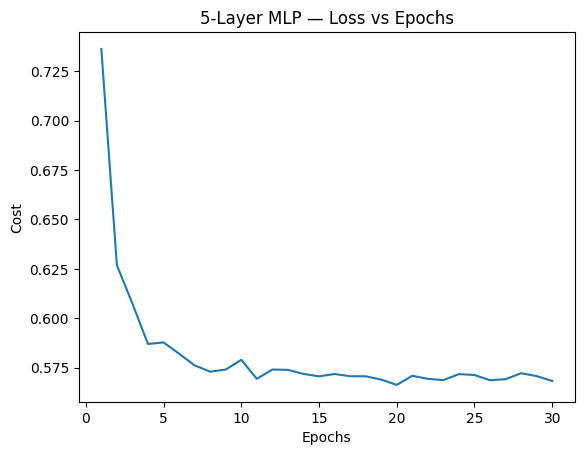

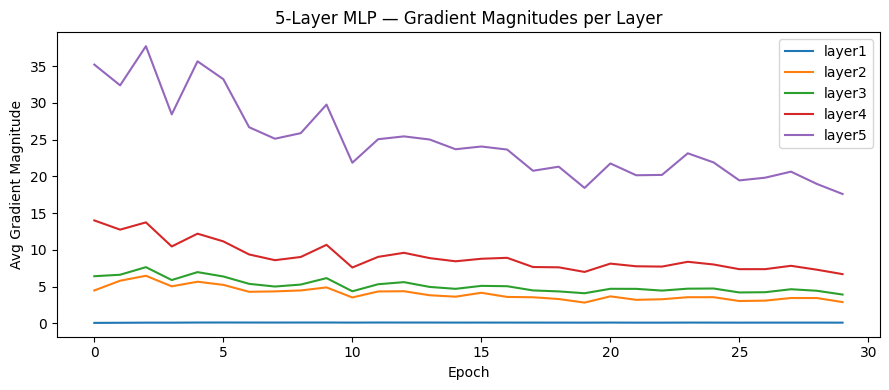

Accuracy: 0.7073019801980198


In [23]:
model5L = TLPVectorizedMiniBatchCrossEntropyGlorot5Layer(
    n_hidden=64, n_hidden2=32, n_hidden3=16, n_hidden4=8,
    C=0.1, epochs=30, eta=0.001,
    alpha=0.001, decrease_const=1e-5,
    minibatches=50, shuffle=True, random_state=1
)
model5L.fit(X_train_ohe, y_train, print_progress=50)

# plot loss
flat_costs = [np.mean(epoch) for epoch in model5L.cost_]
plt.plot(range(1, len(flat_costs)+1), flat_costs)
plt.xlabel('Epochs')
plt.ylabel('Cost')
plt.title('5-Layer MLP — Loss vs Epochs')
plt.show()

# plot gradient magnitudes
model5L.plot_grad_magnitudes()

# evaluate accuracy
y_pred = model5L.predict(X_test_ohe)
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

---
## 5. Adaptive Learning

In [29]:
class TLPVectorizedMiniBatchCrossEntropyGlorot5LayerRMSProp(
    TLPVectorizedMiniBatchCrossEntropyGlorot5Layer
):
    """5-Layer MLP using RMSProp updates with minimal changes from the base 5-layer class."""

    def __init__(self, rms_beta=0.9, rms_eps=1e-8, **kwds):
        super().__init__(**kwds)
        self.rms_beta = rms_beta
        self.rms_eps = rms_eps

    def fit(self, X, y, print_progress=0):
        """Train the 5-layer network using RMSProp."""
        if isinstance(X, pd.DataFrame) or isinstance(X, pd.Series):
            X_data, y_data = X.copy().values, y.copy()
        else:
            X_data, y_data = X.copy(), y.copy()

        Y_enc = self._encode_labels(y)

        self.n_features_ = X_data.shape[1]
        self.n_output_ = Y_enc.shape[0]
        self.W1, self.W2, self.W3, self.W4, self.W5 = self._initialize_weights()

        # RMSProp running average of squared gradients
        Eg2_W1 = np.zeros(self.W1.shape)
        Eg2_W2 = np.zeros(self.W2.shape)
        Eg2_W3 = np.zeros(self.W3.shape)
        Eg2_W4 = np.zeros(self.W4.shape)
        Eg2_W5 = np.zeros(self.W5.shape)

        self.cost_ = []
        self.grad_magnitudes_ = {
            'layer1': [], 'layer2': [], 'layer3': [],
            'layer4': [], 'layer5': []
        }

        for k in range(self.epochs):
            eta = self.eta ** (1 + self.decrease_const * k)
            eta = max(eta, self.eta / 1000)

            if print_progress > 0 and (k + 1) % print_progress == 0:
                sys.stderr.write('\rEpoch: %d/%d' % (k + 1, self.epochs))
                sys.stderr.flush()

            if self.shuffle:
                ridx = np.random.permutation(y_data.shape[0])
                X_data, Y_enc = X_data[ridx], Y_enc[:, ridx]

            mini = np.array_split(range(y_data.shape[0]), self.minibatches)
            mini_cost = []
            epoch_mag1, epoch_mag2, epoch_mag3 = [], [], []
            epoch_mag4, epoch_mag5 = [], []

            for idx in mini:
                A1, Z1, A2, Z2, A3, Z3, A4, Z4, A5, Z5, A6 = self._feedforward(
                    X_data[idx], self.W1, self.W2, self.W3, self.W4, self.W5
                )

                cost = self._cost(
                    A6, Y_enc[:, idx],
                    self.W1, self.W2, self.W3, self.W4, self.W5
                )
                mini_cost.append(cost)

                grad1, grad2, grad3, grad4, grad5 = self._get_gradient(
                    A1=A1, A2=A2, A3=A3, A4=A4, A5=A5, A6=A6,
                    Z1=Z1, Z2=Z2, Z3=Z3, Z4=Z4, Z5=Z5,
                    Y_enc=Y_enc[:, idx],
                    W1=self.W1, W2=self.W2, W3=self.W3, W4=self.W4, W5=self.W5
                )

                epoch_mag1.append(np.mean(np.abs(grad1)))
                epoch_mag2.append(np.mean(np.abs(grad2)))
                epoch_mag3.append(np.mean(np.abs(grad3)))
                epoch_mag4.append(np.mean(np.abs(grad4)))
                epoch_mag5.append(np.mean(np.abs(grad5)))

                # RMSProp update
                Eg2_W1 = self.rms_beta * Eg2_W1 + (1 - self.rms_beta) * (grad1 ** 2)
                Eg2_W2 = self.rms_beta * Eg2_W2 + (1 - self.rms_beta) * (grad2 ** 2)
                Eg2_W3 = self.rms_beta * Eg2_W3 + (1 - self.rms_beta) * (grad3 ** 2)
                Eg2_W4 = self.rms_beta * Eg2_W4 + (1 - self.rms_beta) * (grad4 ** 2)
                Eg2_W5 = self.rms_beta * Eg2_W5 + (1 - self.rms_beta) * (grad5 ** 2)

                self.W1 -= eta * grad1 / (np.sqrt(Eg2_W1) + self.rms_eps)
                self.W2 -= eta * grad2 / (np.sqrt(Eg2_W2) + self.rms_eps)
                self.W3 -= eta * grad3 / (np.sqrt(Eg2_W3) + self.rms_eps)
                self.W4 -= eta * grad4 / (np.sqrt(Eg2_W4) + self.rms_eps)
                self.W5 -= eta * grad5 / (np.sqrt(Eg2_W5) + self.rms_eps)

            self.cost_.append(mini_cost)
            self.grad_magnitudes_['layer1'].append(np.mean(epoch_mag1))
            self.grad_magnitudes_['layer2'].append(np.mean(epoch_mag2))
            self.grad_magnitudes_['layer3'].append(np.mean(epoch_mag3))
            self.grad_magnitudes_['layer4'].append(np.mean(epoch_mag4))
            self.grad_magnitudes_['layer5'].append(np.mean(epoch_mag5))

        return self

In [30]:
# original model (your current update rule)

y_pred_sgd = model5L.predict(X_test_ohe)
acc_sgd = accuracy_score(y_test, y_pred_sgd)
print("SGD-style model Accuracy:", acc_sgd)


# RMSProp model
model5L_rms = TLPVectorizedMiniBatchCrossEntropyGlorot5LayerRMSProp(
    n_hidden=64, n_hidden2=32, n_hidden3=16, n_hidden4=8,
    C=0.1, epochs=30, eta=0.001,
    alpha=0.001,          # unused in RMSProp
    decrease_const=1e-5,
    minibatches=50, shuffle=True, random_state=1,
    rms_beta=0.9, rms_eps=1e-8
)
model5L_rms.fit(X_train_ohe, y_train, print_progress=50)

y_pred_rms = model5L_rms.predict(X_test_ohe)
acc_rms = accuracy_score(y_test, y_pred_rms)
print("RMSProp model Accuracy:", acc_rms)


# compare loss curves
flat_costs_sgd = [np.mean(epoch) for epoch in model5L.cost_]
flat_costs_rms = [np.mean(epoch) for epoch in model5L_rms.cost_]

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(flat_costs_sgd) + 1), flat_costs_sgd, label='SGD-style')
plt.plot(range(1, len(flat_costs_rms) + 1), flat_costs_rms, label='RMSProp')
plt.xlabel('Epochs')
plt.ylabel('Cost')
plt.title('5-Layer MLP — Loss Comparison')
plt.legend()
plt.show()


# optional: gradient magnitudes for RMSProp model
model5L_rms.plot_grad_magnitudes()

SGD-style model Accuracy: 0.7073019801980198


KeyboardInterrupt: 

**Discussion:** *(Which adaptive method did you choose and why? Compare the 5-layer SGD vs adaptive method in terms of convergence speed, final accuracy, and gradient magnitudes.)*

We chose RMSProp as our adaptive learning method because it works by maitaining a running average of the squared gradients for every weight, and then divides it by the learning rate by the square root of that average. As a result, each weight gets its own adaptive learning rate, which gets rid of the vanishing gradient problem that the 5-layer SGD model exhibited. 

Regarding convergence speed, RMSProp was slower at the start as evidenced by the graph above. RMSProp's loss started at around 0.95 while SGD was around 0.75. However, after around 10-12 epochs, RMSProp was able to catch and overtake SGD, continuing to converge to a lower final loss compared to SGD. These results make sense because RMSProp would need those first few initial epochs in order to build up reliable square gradient averages in order for the adapation to occur. Regarding final accuracy, RMSProp was slightly more accurate (~72.4) compared to SGD's 70.7 accuracy.

Overall, RMSProp produced a better final model with better convergence at the cost of an initial "learning" period where it must figure out which weights have large versus small gradients based on the first few epochs. 

We trained both models for 30 epochs because the loss curves for both SGD 
and RMSProp visually stabilize and flatten out by that point, indicating convergence. Running additional epochs would not meaningfully improve performance and would only add unnecessary computation time.

---
## 6. Exceptional Work

In [26]:
class TLPVectorizedMiniBatchCrossEntropyGlorot5LayerAdam(
    TLPVectorizedMiniBatchCrossEntropyGlorot5Layer
):
    """5-Layer MLP using Adam updates with minimal changes from the base 5-layer class."""

    def __init__(self, beta1=0.9, beta2=0.999, adam_eps=1e-8, **kwds):
        super().__init__(**kwds)
        self.beta1 = beta1
        self.beta2 = beta2
        self.adam_eps = adam_eps

    def fit(self, X, y, print_progress=0):
        """Train the 5-layer network using Adam."""
        if isinstance(X, pd.DataFrame) or isinstance(X, pd.Series):
            X_data, y_data = X.copy().values, y.copy()
        else:
            X_data, y_data = X.copy(), y.copy()

        Y_enc = self._encode_labels(y)

        self.n_features_ = X_data.shape[1]
        self.n_output_ = Y_enc.shape[0]
        self.W1, self.W2, self.W3, self.W4, self.W5 = self._initialize_weights()

        # Adam first moment
        mW1 = np.zeros(self.W1.shape)
        mW2 = np.zeros(self.W2.shape)
        mW3 = np.zeros(self.W3.shape)
        mW4 = np.zeros(self.W4.shape)
        mW5 = np.zeros(self.W5.shape)

        # Adam second moment
        vW1 = np.zeros(self.W1.shape)
        vW2 = np.zeros(self.W2.shape)
        vW3 = np.zeros(self.W3.shape)
        vW4 = np.zeros(self.W4.shape)
        vW5 = np.zeros(self.W5.shape)

        self.cost_ = []
        self.grad_magnitudes_ = {
            'layer1': [], 'layer2': [], 'layer3': [],
            'layer4': [], 'layer5': []
        }

        t = 0  # Adam time step

        for k in range(self.epochs):
            eta = self.eta ** (1 + self.decrease_const * k)
            eta = max(eta, self.eta / 1000)

            if print_progress > 0 and (k + 1) % print_progress == 0:
                sys.stderr.write('\rEpoch: %d/%d' % (k + 1, self.epochs))
                sys.stderr.flush()

            if self.shuffle:
                ridx = np.random.permutation(y_data.shape[0])
                X_data, Y_enc = X_data[ridx], Y_enc[:, ridx]

            mini = np.array_split(range(y_data.shape[0]), self.minibatches)
            mini_cost = []
            epoch_mag1, epoch_mag2, epoch_mag3 = [], [], []
            epoch_mag4, epoch_mag5 = [], []

            for idx in mini:
                t += 1

                A1, Z1, A2, Z2, A3, Z3, A4, Z4, A5, Z5, A6 = self._feedforward(
                    X_data[idx], self.W1, self.W2, self.W3, self.W4, self.W5
                )

                cost = self._cost(
                    A6, Y_enc[:, idx],
                    self.W1, self.W2, self.W3, self.W4, self.W5
                )
                mini_cost.append(cost)

                grad1, grad2, grad3, grad4, grad5 = self._get_gradient(
                    A1=A1, A2=A2, A3=A3, A4=A4, A5=A5, A6=A6,
                    Z1=Z1, Z2=Z2, Z3=Z3, Z4=Z4, Z5=Z5,
                    Y_enc=Y_enc[:, idx],
                    W1=self.W1, W2=self.W2, W3=self.W3, W4=self.W4, W5=self.W5
                )

                epoch_mag1.append(np.mean(np.abs(grad1)))
                epoch_mag2.append(np.mean(np.abs(grad2)))
                epoch_mag3.append(np.mean(np.abs(grad3)))
                epoch_mag4.append(np.mean(np.abs(grad4)))
                epoch_mag5.append(np.mean(np.abs(grad5)))

                # First moment
                mW1 = self.beta1 * mW1 + (1 - self.beta1) * grad1
                mW2 = self.beta1 * mW2 + (1 - self.beta1) * grad2
                mW3 = self.beta1 * mW3 + (1 - self.beta1) * grad3
                mW4 = self.beta1 * mW4 + (1 - self.beta1) * grad4
                mW5 = self.beta1 * mW5 + (1 - self.beta1) * grad5

                # Second moment
                vW1 = self.beta2 * vW1 + (1 - self.beta2) * (grad1 ** 2)
                vW2 = self.beta2 * vW2 + (1 - self.beta2) * (grad2 ** 2)
                vW3 = self.beta2 * vW3 + (1 - self.beta2) * (grad3 ** 2)
                vW4 = self.beta2 * vW4 + (1 - self.beta2) * (grad4 ** 2)
                vW5 = self.beta2 * vW5 + (1 - self.beta2) * (grad5 ** 2)

                # Bias correction
                mW1_hat = mW1 / (1 - self.beta1 ** t)
                mW2_hat = mW2 / (1 - self.beta1 ** t)
                mW3_hat = mW3 / (1 - self.beta1 ** t)
                mW4_hat = mW4 / (1 - self.beta1 ** t)
                mW5_hat = mW5 / (1 - self.beta1 ** t)

                vW1_hat = vW1 / (1 - self.beta2 ** t)
                vW2_hat = vW2 / (1 - self.beta2 ** t)
                vW3_hat = vW3 / (1 - self.beta2 ** t)
                vW4_hat = vW4 / (1 - self.beta2 ** t)
                vW5_hat = vW5 / (1 - self.beta2 ** t)

                # Adam update
                self.W1 -= eta * mW1_hat / (np.sqrt(vW1_hat) + self.adam_eps)
                self.W2 -= eta * mW2_hat / (np.sqrt(vW2_hat) + self.adam_eps)
                self.W3 -= eta * mW3_hat / (np.sqrt(vW3_hat) + self.adam_eps)
                self.W4 -= eta * mW4_hat / (np.sqrt(vW4_hat) + self.adam_eps)
                self.W5 -= eta * mW5_hat / (np.sqrt(vW5_hat) + self.adam_eps)

            self.cost_.append(mini_cost)
            self.grad_magnitudes_['layer1'].append(np.mean(epoch_mag1))
            self.grad_magnitudes_['layer2'].append(np.mean(epoch_mag2))
            self.grad_magnitudes_['layer3'].append(np.mean(epoch_mag3))
            self.grad_magnitudes_['layer4'].append(np.mean(epoch_mag4))
            self.grad_magnitudes_['layer5'].append(np.mean(epoch_mag5))

        return self

SGD-style model Accuracy: 0.7073019801980198
Adam model Accuracy: 0.7257288228822882


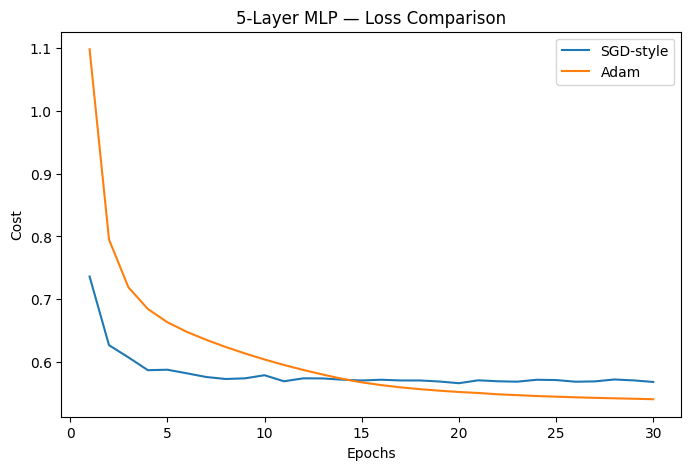

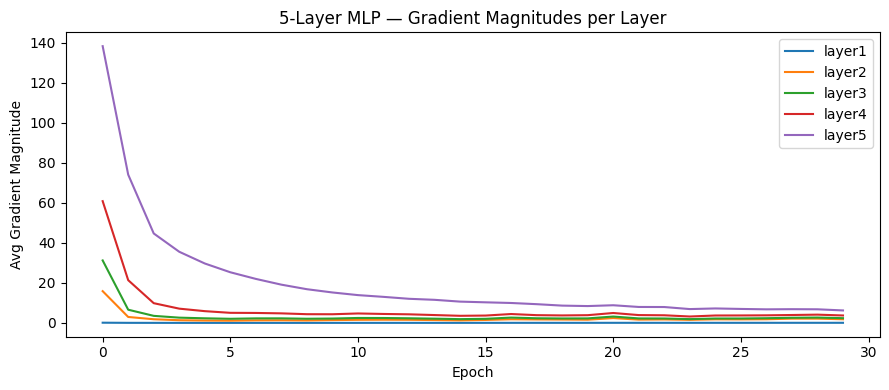

In [27]:
# original model

y_pred_sgd = model5L.predict(X_test_ohe)
acc_sgd = accuracy_score(y_test, y_pred_sgd)
print("SGD-style model Accuracy:", acc_sgd)


# Adam model
model5L_adam = TLPVectorizedMiniBatchCrossEntropyGlorot5LayerAdam(
    n_hidden=64, n_hidden2=32, n_hidden3=16, n_hidden4=8,
    C=0.1, epochs=30, eta=0.001,
    alpha=0.001,              # unused by Adam, kept for consistency
    decrease_const=1e-5,
    minibatches=50, shuffle=True, random_state=1,
    beta1=0.9, beta2=0.999, adam_eps=1e-8
)
model5L_adam.fit(X_train_ohe, y_train, print_progress=50)

y_pred_adam = model5L_adam.predict(X_test_ohe)
acc_adam = accuracy_score(y_test, y_pred_adam)
print("Adam model Accuracy:", acc_adam)


# compare loss curves
flat_costs_sgd = [np.mean(epoch) for epoch in model5L.cost_]
flat_costs_adam = [np.mean(epoch) for epoch in model5L_adam.cost_]

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(flat_costs_sgd) + 1), flat_costs_sgd, label='SGD-style')
plt.plot(range(1, len(flat_costs_adam) + 1), flat_costs_adam, label='Adam')
plt.xlabel('Epochs')
plt.ylabel('Cost')
plt.title('5-Layer MLP — Loss Comparison')
plt.legend()
plt.show()


# optional gradient magnitude plot
model5L_adam.plot_grad_magnitudes()

                     Model  Test Accuracy  Final Loss
               3-Layer MLP       0.729510    0.406985
        5-Layer MLP (Adam)       0.725729    0.540827
Model 3 - Normalized + OHE       0.725591    0.427886
     5-Layer MLP (RMSProp)       0.723804    0.547605
               4-Layer MLP       0.723047    0.463433
         5-Layer MLP (SGD)       0.707302    0.568316
      Model 2 - Normalized       0.251513    0.920397
Model 1 - No Preprocessing       0.249725    1.500853


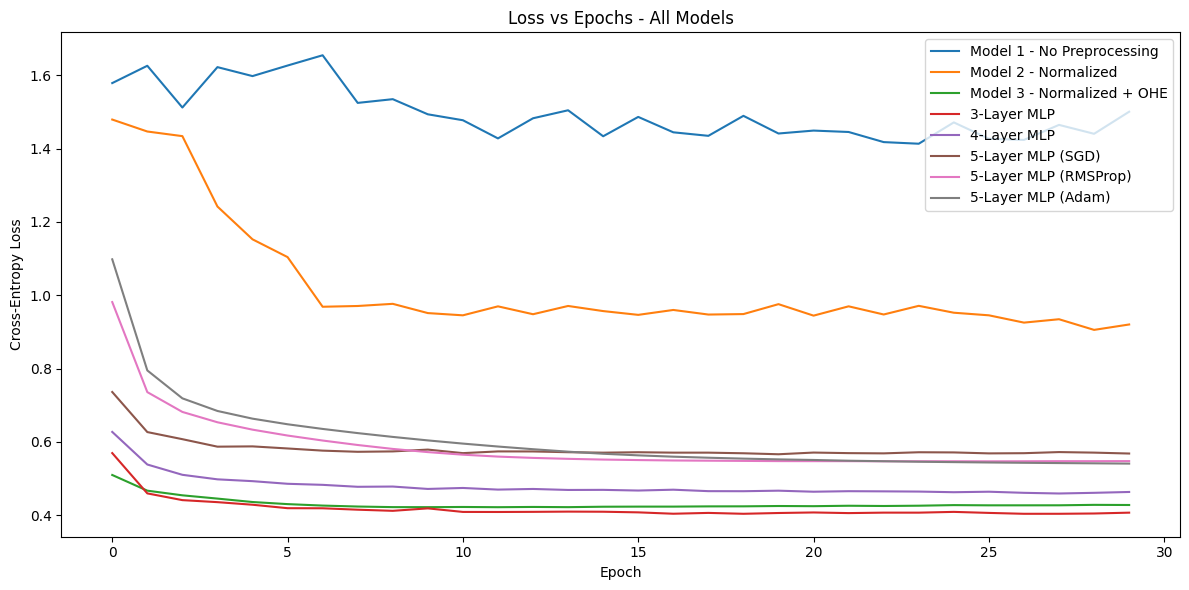

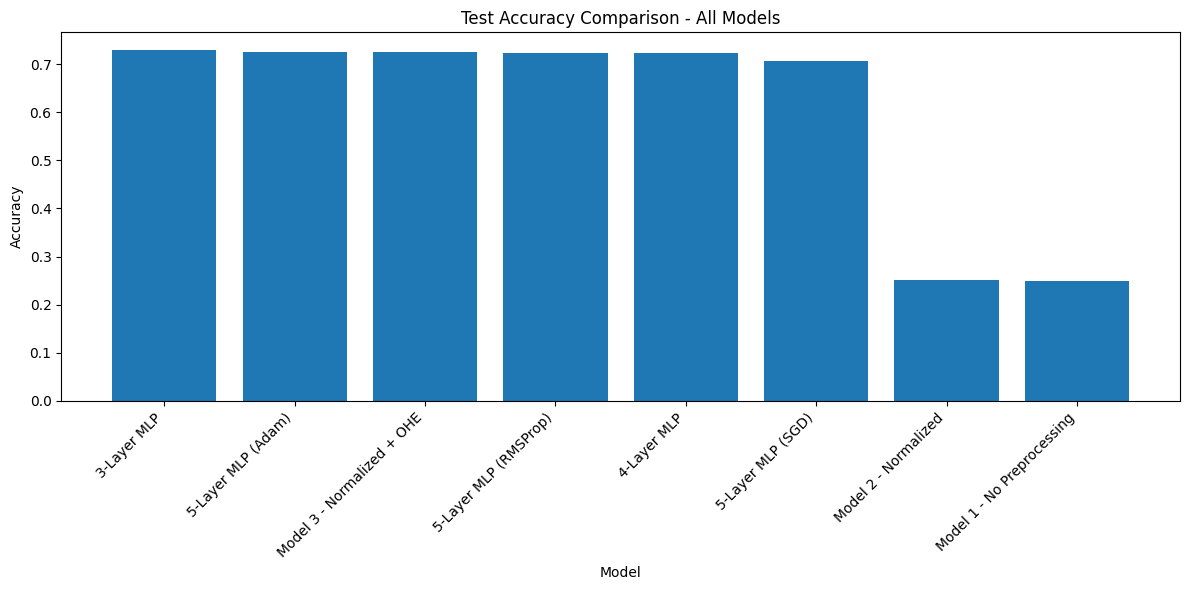

In [28]:
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def flatten_costs(model):
    """Turn model.cost_ into a clean per-epoch list."""
    flat = []
    for epoch in model.cost_:
        if isinstance(epoch, (list, tuple, np.ndarray)):
            flat.append(np.mean(epoch))
        else:
            flat.append(epoch)
    return flat

def evaluate_model(model, X_test, y_test):
    """Return test accuracy for a fitted model."""
    y_pred = model.predict(X_test)
    return accuracy_score(y_test, y_pred)

# --------------------------------------------------
# Add whichever trained models you want to compare
# Format: (display_name, model_object, X_test_used)
# --------------------------------------------------
models_to_compare = [
    ("Model 1 - No Preprocessing", mlp1, X_test),
    ("Model 2 - Normalized", mlp2, X_test_norm),
    ("Model 3 - Normalized + OHE", mlp3, X_test_ohe),
    ("3-Layer MLP", model3L, X_test_ohe),
    ("4-Layer MLP", model4L, X_test_ohe),
    ("5-Layer MLP (SGD)", model5L, X_test_ohe),
    ("5-Layer MLP (RMSProp)", model5L_rms, X_test_ohe),
    ("5-Layer MLP (Adam)", model5L_adam, X_test_ohe),
]

# --------------------------------------------------
# Build comparison table
# --------------------------------------------------
results = []

for name, model, X_eval in models_to_compare:
    acc = evaluate_model(model, X_eval, y_test)
    final_loss = flatten_costs(model)[-1]
    results.append({
        "Model": name,
        "Test Accuracy": acc,
        "Final Loss": final_loss
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Test Accuracy", ascending=False).reset_index(drop=True)

print(results_df.to_string(index=False))

# --------------------------------------------------
# Plot all loss curves together
# --------------------------------------------------
plt.figure(figsize=(12, 6))

for name, model, _ in models_to_compare:
    plt.plot(flatten_costs(model), label=name)

plt.title("Loss vs Epochs - All Models")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.legend()
plt.tight_layout()
plt.show()

# --------------------------------------------------
# Plot accuracy comparison
# --------------------------------------------------
plt.figure(figsize=(12, 6))
plt.bar(results_df["Model"], results_df["Test Accuracy"])
plt.title("Test Accuracy Comparison - All Models")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---
## Summary

| Model | Test Accuracy |
|---|---|
| 1 — 2-layer, no preprocessing | |
| 2 — 2-layer, normalized | |
| 3 — 2-layer, normalized + OHE | |
| 3-layer MLP | |
| 4-layer MLP | |
| 5-layer MLP (SGD) | |
| 5-layer MLP (adaptive) | |